# 🇰🇷 실시간 연계: 브이월드 API 활용 대한민국 3D 도시 모델링 (최종 수정판)

이 노트북은 브이월드 API의 최신 레이어 명칭 및 속성명을 반영하여 에러 없이 실행되도록 최적화되었습니다.

## 🔑 1. API 키 설정
브이월드에서 발급받은 키를 입력하세요. 도메인은 `http://localhost`로 등록되어 있어야 합니다.

In [6]:
import requests
import geopandas as gpd
import pandas as pd
from voxcity.generator import get_voxcity
from voxcity.visualizer.renderer import visualize_voxcity_plotly

VWORLD_KEY = "370CC5CA-09DA-3A55-87BD-A6697CB0328E" 
print("라이브러리 및 API 키 준비 완료")

라이브러리 및 API 키 준비 완료


## 🌐 2. 브이월드 데이터 수집
최신 레이어인 `LT_C_SPBD`(건물통합정보)를 사용합니다.

In [7]:
bbox = "126.970,37.553,126.972,37.555" # 서울역사 인근 (데이터 확실한 구역)
data_layer = "LT_C_SPBD"

url = f"http://api.vworld.kr/req/data?service=data&request=GetFeature&data={data_layer}&key={VWORLD_KEY}&domain=http://localhost&geomFilter=BOX({bbox})"

response = requests.get(url)
data = response.json()

if 'response' in data and data['response'].get('status') == 'OK':
    features = data['response']['result']['featureCollection']['features']
    vworld_gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
    print(f"✅ 성공: {len(vworld_gdf)}개의 건물 데이터 수집 완료")
else:
    print("❌ 데이터 수집 실패. API 응답을 확인하세요:", data.get('response', {}).get('error', {}).get('text'))

✅ 성공: 4개의 건물 데이터 수집 완료


## 🛠️ 3. 데이터 가공 및 VoxCity 실행
속성명 불일치 문제를 해결하기 위해 유연한 컬럼 매핑 로직을 적용했습니다.

INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_source, land_cover_source, canopy_height_source, building_complementary_source


✅ 속성 'gro_flo_co'을 기반으로 높이 계산 완료
Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (126.9710, 37.5540): Korea, Republic of
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=None
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=High Resolution 1m Global Canopy Height Maps | https://gee-community-catalog.org/projects/meta_trees/
INFO | voxcity.voxcity.generator.api | - DEM=Flat
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.generator.grids | Creating Land Use Land Cover grid
 
INFO | voxcity.voxcity.generator.grids | Data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | 
OpenStreetMap Land Cover Classes (source-specific, 0-based indices):
------------------------------------------------

Fetching data from Overpass API...
Converting data to GeoJSON format...


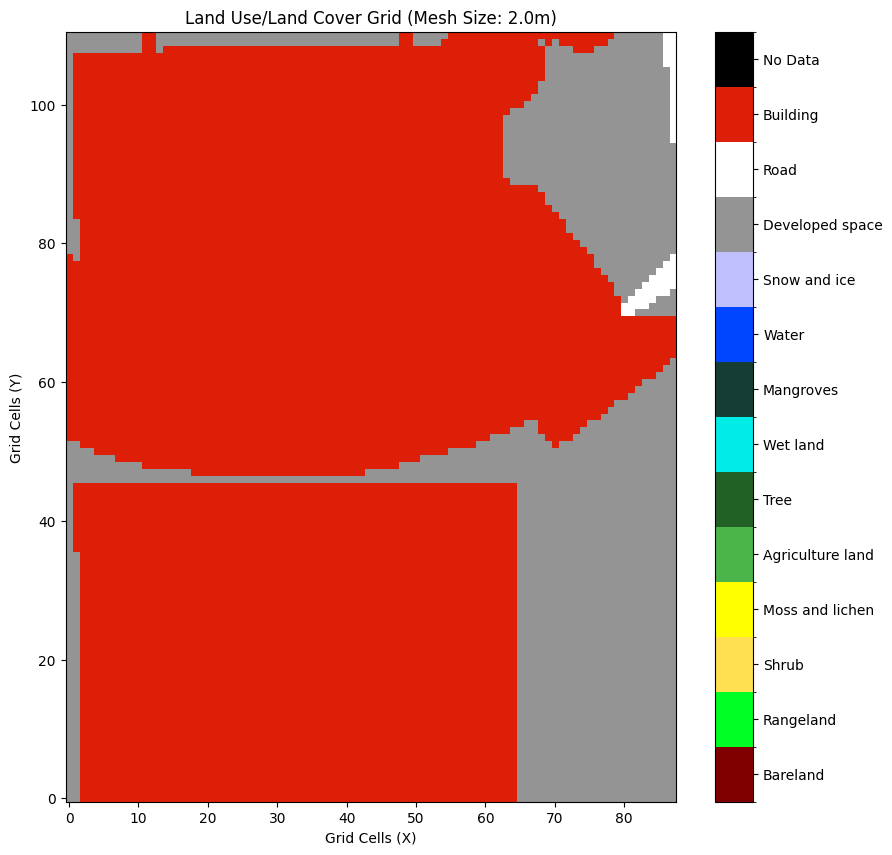

INFO | voxcity.voxcity.generator.grids | Creating Building Height grid
 
INFO | voxcity.voxcity.generator.grids | Base data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | Using provided GeoDataFrame for building data
INFO | voxcity.voxcity.generator.grids | Complementary data source: None
INFO | voxcity.voxcity.geoprocessor.raster.buildings | 1 of the total 4 building footprint from the base data source did not have height data.


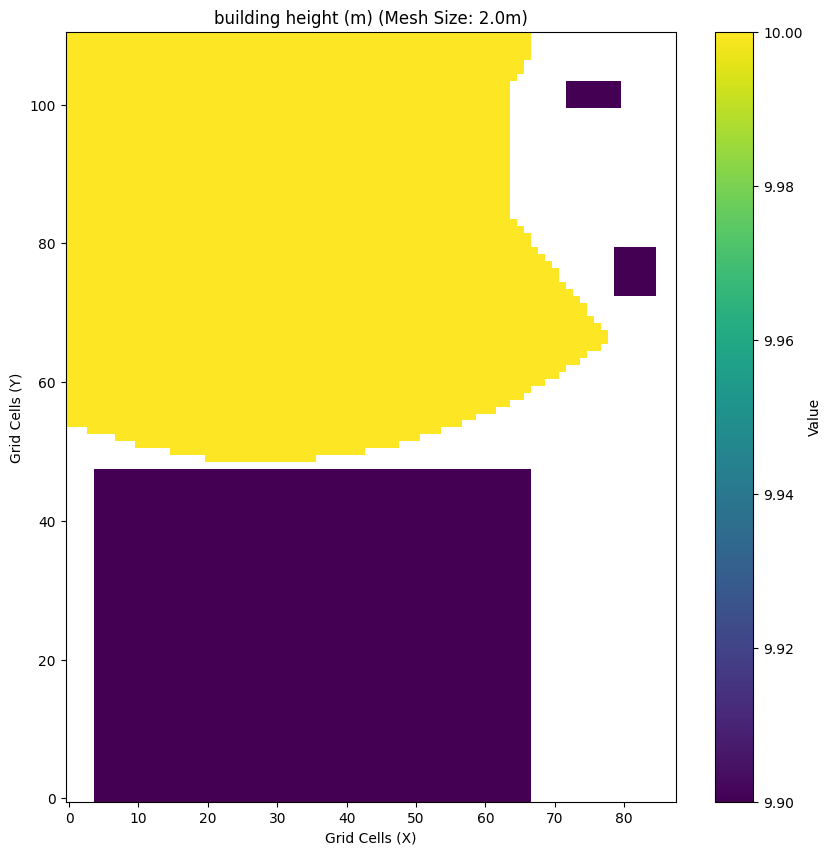

INFO | voxcity.voxcity.generator.grids | Creating Canopy Height grid
 
INFO | voxcity.voxcity.generator.grids | Data source: High Resolution 1m Global Canopy Height Maps


Generating URL ...
Please wait ...
Data downloaded to D:\repository\VoxCity\docs\examples\output\canopy_height.tif


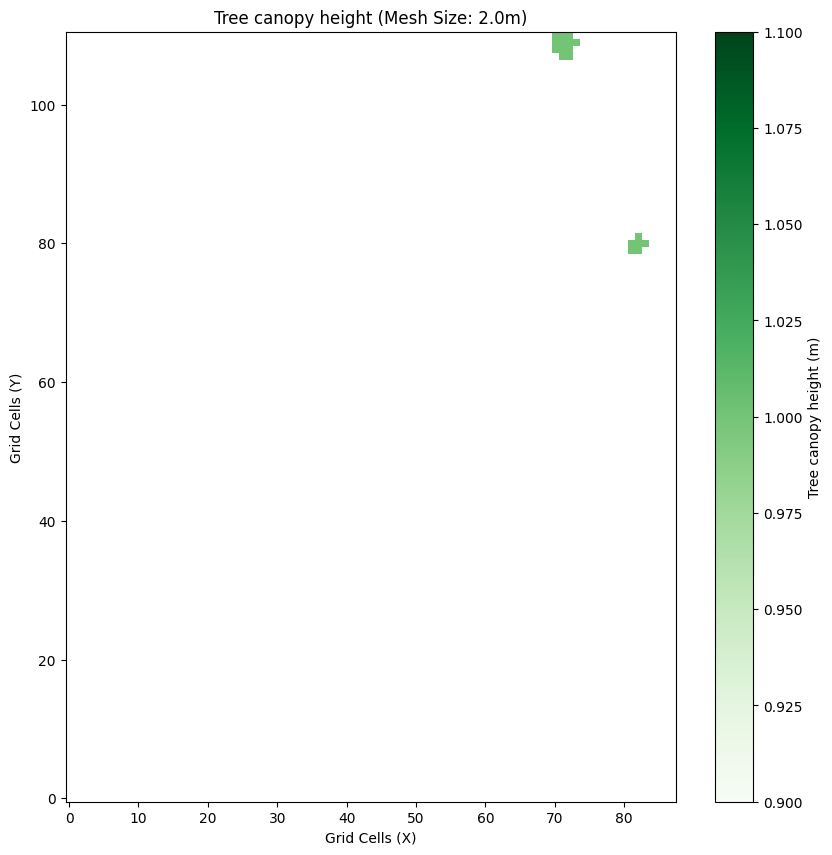

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/voxcity.h5


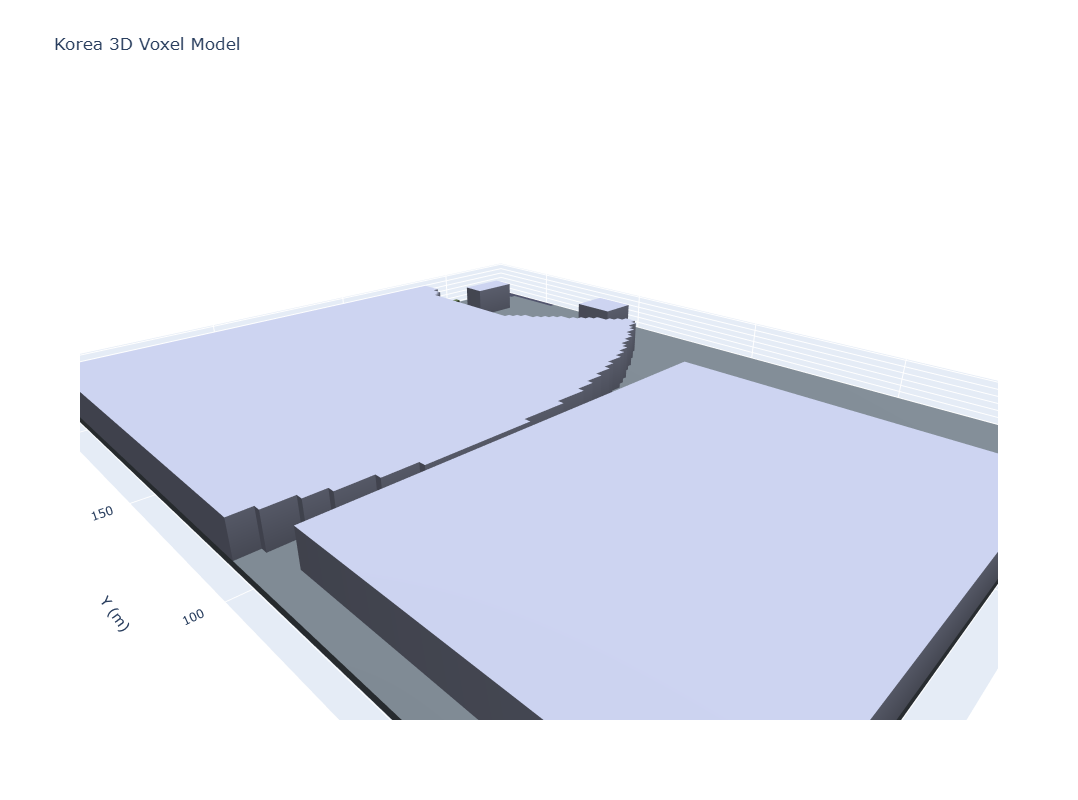

In [8]:
if 'vworld_gdf' in locals():
    # 1. 층수 컬럼 식별 (gro_flo_co 또는 gr_flo_co)
    possible_cols = ['gro_flo_co', 'gr_flo_co', 'GRO_FLO_CO', 'GR_FLO_CO']
    target_col = next((c for c in possible_cols if c in vworld_gdf.columns), None)
    
    if target_col:
        vworld_gdf['height'] = pd.to_numeric(vworld_gdf[target_col], errors='coerce').fillna(1) * 3.3
        building_data = vworld_gdf[['height', 'geometry']]
        print(f"✅ 속성 '{target_col}'을 기반으로 높이 계산 완료")
        
        # 2. VoxCity 모델 생성
        rectangle_vertices = [(126.970, 37.553), (126.970, 37.555), (126.972, 37.555), (126.972, 37.553)]
        city = get_voxcity(rectangle_vertices, meshsize=2.0, building_gdf=building_data, dem_source='Flat')
        
        # 3. 3D 시각화
        visualize_voxcity_plotly(city.voxels.classes, city.voxels.meta.meshsize, title="Korea 3D Voxel Model")
    else:
        print("❌ 층수 데이터를 찾을 수 없습니다. 속성 목록:", vworld_gdf.columns.tolist())